In [ ]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import umap
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import commons, models, utils, losses, lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDiseaseBinaryBatchSampler

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")
args = parser.parse_args(["--model_name", "peftwavlm_ssccl_patient"])

model_dir = os.path.join("./logs", args.model_name)
config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()
config = json.loads(data)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training
hps.data.ssccl_training = hps.train.ssccl_training
hps.model.spk_dim = 0

logger = utils.get_logger(hps.model_dir)
if args.init:
    pool_net = getattr(models, hps.model.pooling_model)
    shutil.copy2('./models.py', f'{hps.model_dir}/model_net.py.bak')
else:
    import sys, importlib.util, shutil, tempfile
    temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
    shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
    spec = importlib.util.spec_from_file_location("model_net", temp_path)
    model_net = importlib.util.module_from_spec(spec)
    sys.modules["model_net"] = model_net
    spec.loader.exec_module(model_net)
    pool_net = getattr(model_net, hps.model.pooling_model)

hps.model.lora_finetune = False
pool_model = pool_net(hps.model.feature_dim, **hps.model)

runner_lightning = lightning_wrapper.CoughClassificationRunner(pool_model, hps=hps, custom_logger=logger, class_weights=[])
runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
    os.path.join(f"{hps.model_dir}/best_model.ckpt"),
    model=pool_model,
    hps=hps, custom_logger=logger
)
runner_lightning.eval()

df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

# print(df_train['db'].value_counts())
# print(df_train['disease_status'].value_counts())
# #df_train = df_train[~df_train['db'].isin([0, 1])]

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)
target_labels = df_train[hps.data.target_column]

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_60321/2661047540.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


INFO:peftwavlm_ssccl_patient:Trainable params: 319770560 | Total params: 323977152 | Trainable%: 98.70% | Size: 319.77M
INFO:peftwavlm_ssccl_patient:Trainable params: 319770560 | Total params: 323977152 | Trainable%: 98.70% | Size: 319.77M


In [3]:
fold = 0
train_dataset = CoughDatasets(df_train.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

test_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
test_loader = DataLoader(test_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

In [4]:
trainer = L.Trainer(
       max_epochs=1000,
       accelerator="gpu" if torch.cuda.is_available() else "cpu",
       devices="auto",
       default_root_dir=hps.model_dir
    )

trainer.validate(runner_lightning, dataloaders=test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:484: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val/loss          │    0.2135644108057022     │
└───────────────────────────┴───────────────────────────┘

[{'val/loss': 0.2135644108057022}]

In [11]:
train_embeds = []
train_labels = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
        _, audio, _, attention_masks, dse_ids, [patient_ids, _] = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.model._forward_encoder(audio, attention_mask=attention_masks)
        embed = out_model#['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_embeds.append(embed.cpu())
        train_labels.append(patient_ids.cpu())

train_embeds = torch.cat(train_embeds, dim=0).numpy()
train_labels = torch.cat(train_labels, dim=0).numpy()

test_embeds = []
test_labels = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
        _, audio, _, attention_masks, dse_ids, [patient_ids, _] = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.model._forward_encoder(audio, attention_mask=attention_masks)
        embed = out_model#['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        test_embeds.append(embed.cpu())
        test_labels.append(patient_ids.cpu())

del audio, attention_masks
test_embeds = torch.cat(test_embeds, dim=0).numpy()
test_labels = torch.cat(test_labels, dim=0).numpy()

100%|██████████| 156/156 [00:32<00:00,  4.87it/s]


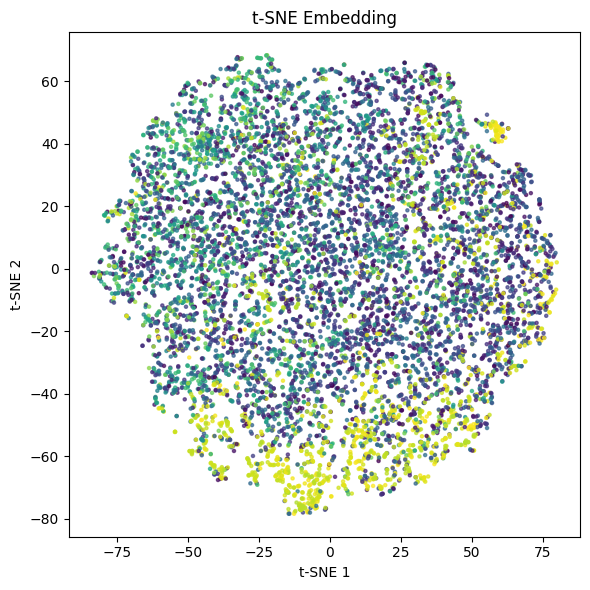

In [ ]:
mask_1 = train_labels
all_embeds_train = train_embeds#[mask_1]
all_labels_train = train_labels#[mask_1]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_2d = tsne.fit_transform(train_embeds)

plt.figure(figsize=(6, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    s=5,
    c=train_labels,
    alpha=0.7
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Embedding")
plt.tight_layout()
plt.show()

In [ ]:
mask_0 = all_labels == 0
mask_1 = all_labels == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(all_embeds)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("Phase-1 Embedding Space (Label 0 vs 1)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [ ]:
from cleanlab.filter import find_label_issues
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict

model_xgb = XGBClassifier(tree_method="hist", enable_categorical=True)
model_xgb.fit(train_embeds, train_labels)

preds = model_xgb.predict(test_embeds)
acc_original = accuracy_score(preds, test_labels)
print(f"Accuracy with original data: {round(acc_original*100,1)}%")

In [ ]:
model_xgb = XGBClassifier(tree_method="hist", enable_categorical=True)
pred_probs = cross_val_predict(model_xgb, train_embeds, train_labels, method='predict_proba')
issue_idx = find_label_issues(train_labels.astype(np.int32).tolist(), pred_probs, return_indices_ranked_by='self_confidence')

cv_accuracy = (pred_probs.argmax(axis=1) == train_labels).mean()
print(f"Cross-validated estimate of accuracy on held-out data: {cv_accuracy}")

In [ ]:
mask_clean = torch.ones(len(train_embeds), dtype=torch.bool)
mask_clean[issue_idx] = False

train_embeds_clean = train_embeds[mask_clean]
train_labels_clean = train_labels[mask_clean]

model_xgb = XGBClassifier(tree_method="hist", enable_categorical=True)
pred_probs = cross_val_predict(model_xgb, train_embeds_clean, train_labels_clean, method='predict_proba')
cv_accuracy = (pred_probs.argmax(axis=1) == train_labels_clean).mean()
print(f"Cross-validated estimate of accuracy on held-out data: {cv_accuracy}")

model_xgb = XGBClassifier(tree_method="hist", enable_categorical=True)
model_xgb.fit(train_embeds_clean, train_labels_clean)

preds = model_xgb.predict(test_embeds)
acc_original = accuracy_score(preds, test_labels)
print(f"Accuracy with original data: {round(acc_original*100,1)}%")

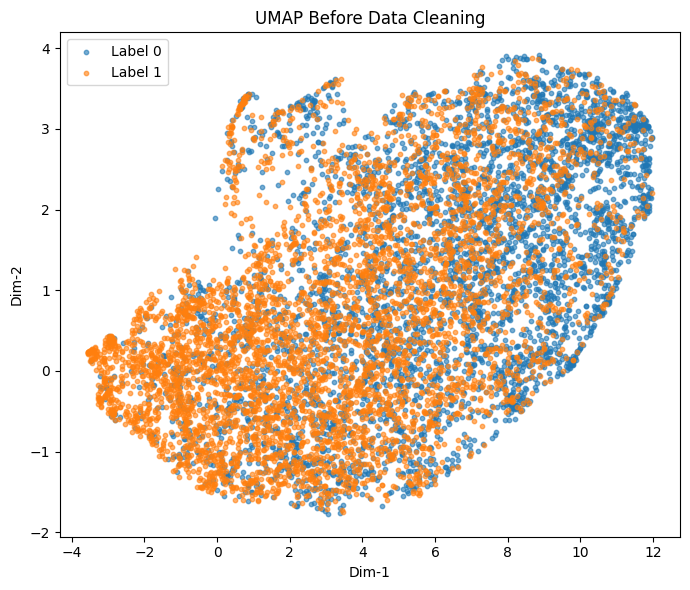

In [31]:
mask_0 = train_labels == 0
mask_1 = train_labels == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(train_embeds)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("UMAP Before Data Cleaning")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

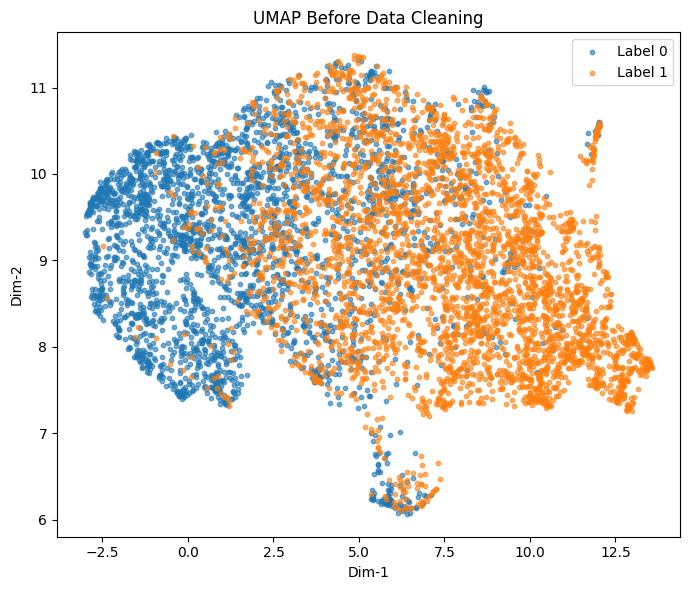

In [32]:
mask_0 = train_labels_clean == 0
mask_1 = train_labels_clean == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(train_embeds_clean)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("UMAP Before Data Cleaning")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [ ]:
len(train_embeds_clean)

In [ ]:
mask_0 = all_labels_clean == 0
mask_1 = all_labels_clean == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(all_embeds_clean)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("Phase-1 Embedding Space (Label 0 vs 1)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [ ]:
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/cirdz/metadata_wavs_capped.csv')
df_test = df_test.reset_index(drop=True)
df_test = df_test[hps.data.column_order]
val_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

all_embeds_cirdz = []
all_labels_cirdz = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(val_loader), total=len(val_loader)):
        _, audio, _, attention_masks, dse_ids, _ = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.forward(audio, attention_mask=attention_masks)
        embed = out_model['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        all_embeds_cirdz.append(embed.cpu())
        all_labels_cirdz.append(dse_ids.cpu())

del audio, attention_masks
all_embeds_cirdz = torch.cat(all_embeds_cirdz, dim=0).numpy()
all_labels_cirdz = torch.cat(all_labels_cirdz, dim=0).numpy()

mask_1 = all_labels_cirdz == 1
all_embeds_cirdz = all_embeds_cirdz[mask_1]
all_labels_cirdz = all_labels_cirdz[mask_1]
all_labels_cirdz[:] = 0

In [ ]:
all_embeds = np.concatenate([all_embeds_train, all_embeds_cirdz], axis=0)
all_labels = np.concatenate([all_labels_train, all_labels_cirdz], axis=0)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_2d = tsne.fit_transform(all_embeds)

plt.figure(figsize=(6, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    s=5,
    c=all_labels,
    alpha=0.7
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Embedding")
plt.tight_layout()
plt.show()

In [ ]:
mask_0 = all_labels == 0
mask_1 = all_labels == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(all_embeds)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("Phase-1 Embedding Space (Label 0 vs 1)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [ ]:
all_embeds[mask_1]

In [ ]:
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/cirdz/metadata_wavs_capped.csv')
df_test = df_test.reset_index(drop=True)
df_test = df_test[hps.data.column_order]
val_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

all_embeds_cirdz = []
all_labels_cirdz = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(val_loader), total=len(val_loader)):
        _, audio, _, attention_masks, dse_ids, _ = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.forward(audio, attention_mask=attention_masks)
        embed = out_model['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        all_embeds_cirdz.append(embed.cpu())
        all_labels_cirdz.append(dse_ids.cpu())

del audio, attention_masks
all_embeds_cirdz = torch.cat(all_embeds_cirdz, dim=0).numpy()
all_labels_cirdz = torch.cat(all_labels_cirdz, dim=0).numpy()

In [ ]:
all_embeds = []
all_labels = []

with torch.no_grad():
    for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
        _, audio, _, attention_masks, dse_ids, _ = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.forward(audio, attention_mask=attention_masks)
        embed = out_model['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        all_embeds.append(embed.cpu())
        all_labels.append(dse_ids.cpu())

del audio, attention_masks
all_embeds = torch.cat(all_embeds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

In [ ]:
plt.figure(figsize=(7, 6))
#plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("Phase-1 Embedding Space (Label 0 vs 1)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [ ]:
#mask_0 = all_labels == 0
mask_1 = all_labels == 1




In [ ]:
emb_2d.shape

In [ ]:

#######################################################################
parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")
args = parser.parse_args()

model_dir = os.path.join("./logs", args.model_name)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

port = utils.get_free_port()
subprocess.Popen(
    ["tensorboard", "--logdir", model_dir, "--port", str(port), "--host", "0.0.0.0"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)

config_save_path = os.path.join(model_dir, "config.json")
if args.init:
    with open(args.config_path, "r") as f:
        data = f.read()
    with open(config_save_path, "w") as f:
        f.write(data)
else:
    with open(config_save_path, "r") as f:
        data = f.read()
config = json.loads(data)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training
hps.data.ssccl_training = hps.train.ssccl_training

# =============================================================
# SECTION: Loading Data
# =============================================================
df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

# print(df_train['db'].value_counts())
# print(df_train['disease_status'].value_counts())
# #df_train = df_train[~df_train['db'].isin([0, 1])]

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)
target_labels = df_train[hps.data.target_column]
# =============================================================
# SECTION: Model Setup
# =============================================================
logger = utils.get_logger(hps.model_dir)
logger.info(hps)

logger.info(f"======================================")
logger.info(f"✨ Loss: {hps.train.loss_function}")
logger.info(f"✨ Use Between Class Training: {hps.data.mix_audio}")
logger.info(f"✨ Use Augment: {hps.data.augment_data}")
logger.info(f"✨ Use Augment: Prob {hps.data.augment_prob}")
logger.info(f"✨ Use Rawboost Augment: {hps.data.augment_rawboost}")
logger.info(f"✨ Padding Type: {hps.data.pad_types}")
logger.info(f"✨ Using Model: {hps.model.pooling_model}")
logger.info(f"✨ Tensorboard: http://100.101.198.75:{port}/#scalars&_smoothingWeight=0")
logger.info(f"======================================")

hps.model.spk_dim = 0
if args.init:
    pool_net = getattr(models, hps.model.pooling_model)
    pool_model = pool_net(hps.model.feature_dim, **hps.model)
    shutil.copy2('./models.py', f'{hps.model_dir}/model_net.py.bak')
else:
    import sys, importlib.util, shutil, tempfile
    temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
    shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
    spec = importlib.util.spec_from_file_location("model_net", temp_path)
    pool_model = importlib.util.module_from_spec(spec)
    sys.modules["model_net"] = pool_model
    spec.loader.exec_module(pool_model)